In [1]:
import math
import pandas as pd

df = pd.read_csv("Ads_CTR_Optimisation.csv")

N, d = df.shape
print(N,d)


10000 10


In [2]:
numbers_of_selections = [0] * d #her bir reklamın kaç kere gösterildiği 
sums_of_rewards = [0] * d #her reklamın toplamda kaç kere tıklandığı
total_reward = 0 
ads_selected = []

In [ ]:
for user in range(N):
    selected_ad = 0
    max_upper_bound = 0
    for ad in range (d):
        if numbers_of_selections[ad] > 0: 
            average_reward = sums_of_rewards[ad] / numbers_of_selections[ad]
            current_round = user +  1 # indexle gittiğimiz için + 1
            selection_count = numbers_of_selections[ad] # her bşr reklamın kaç kere sayıldığı
            delta = math.sqrt(1.5 * math.log(current_round) / selection_count) # delta fonk

            upper_bound = average_reward + delta
        else:
            upper_bound = math.inf

        if upper_bound > max_upper_bound: # en maxı bulmak için kıyaslama yapıyoruz daha büyük bir değer çıkarsa o max olur
            max_upper_bound = upper_bound
            selected_ad = ad

    ads_selected.append(selected_ad)
    numbers_of_selections[selected_ad] += 1

    reward = df.values[user,selected_ad]
    sums_of_rewards[selected_ad] += reward

    total_reward += reward


In [4]:
print(f"UCB için Toplam Tıklama Sayısı: {total_reward}")
print("Reklamların Gösterilme Sayıları:", numbers_of_selections)

UCB için Toplam Tıklama Sayısı: 2178
Reklamların Gösterilme Sayıları: [705, 387, 186, 345, 6323, 150, 292, 1170, 256, 186]


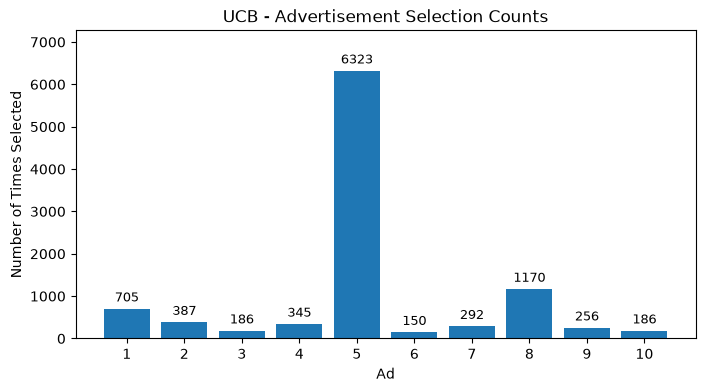

In [5]:
import matplotlib.pyplot as plt

counts = [ads_selected.count(i) for i in range(d)]

plt.figure(figsize=(8, 4))

bars = plt.bar(range(1, d + 1), counts)

plt.bar_label(bars, padding=3, fontsize=9)
plt.ylim(0, max(counts) * 1.15)

plt.title("UCB - Advertisement Selection Counts")
plt.xlabel("Ad")
plt.ylabel("Number of Times Selected")
plt.xticks(range(1, d + 1))

plt.show()